### Dataset Overview

**Key Observations**
-dataset has millions of transactions with numerical and categorical features present
-Balance related features are included for both sender and receiver accounts


In [1]:
#core libraries
import pandas as pd
import numpy as np
#visualization for later in EDA
import matplotlib.pyplot as plt
import seaborn as sns
#optional display settings
pd.set_option('display.max_columns', None)
sns.set(style= "whitegrid")

In [2]:
df = pd.read_csv("../data/raw/PS_20174392719_1491204439457_log.csv")
df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df.shape
df.info()

df['isFraud'].value_counts(normalize=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64

### Class Imbalance
The distribution of fraud vs non-fraud transactions was examined.

**Observations
-Fraud transactions make up a very small portion of the overall data set (~0.1-0.2%)
-Dataset is also imbalanced

**Thoughts
-Fraud may tend to be rare and detection may also be challenging because of this. Modeling will require careful handling


In [5]:
# Compare fraud by payment type
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
print(fraud_by_type)

# Compare average amount by payment type
amount_by_type = df.groupby("type")["amount"].mean().sort_values(ascending=False)
print(amount_by_type)

# Compare average amount for fraud vs non-fraud
amount_by_fraud = df.groupby("isFraud")["amount"].mean()
print(amount_by_fraud)

type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64
type
TRANSFER    910647.009645
CASH_OUT    176273.964346
CASH_IN     168920.242004
PAYMENT      13057.604660
DEBIT         5483.665314
Name: amount, dtype: float64
isFraud
0    1.781970e+05
1    1.467967e+06
Name: amount, dtype: float64


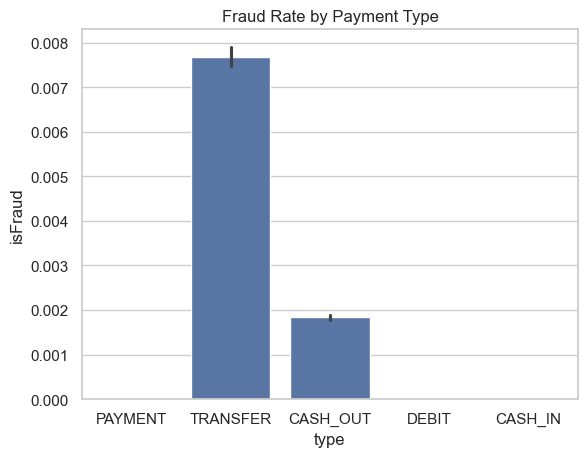

In [6]:
sns.barplot(data=df, x="type", y="isFraud")
plt.title("Fraud Rate by Payment Type")
plt.show()

### Fraud by Transaction type

**Observations
-Fraud is primarily in TRANSFER transactions
-A smaller amount is in CASH_OUT
-Fraud wasn't found in the other payment types

**Thoughts
-Fraud is concentrated in transfer payment types instead of being distributed throughout the database.

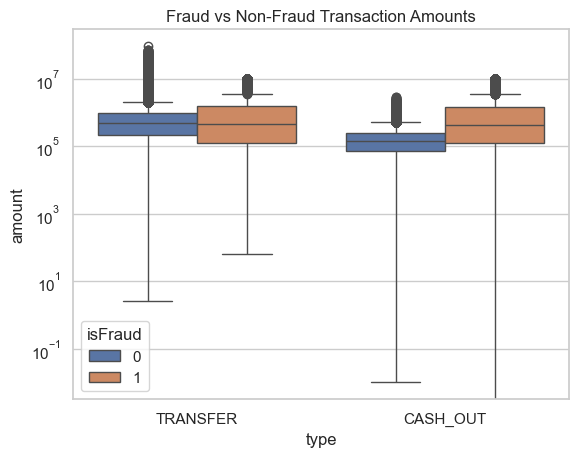

In [7]:
sns.boxplot(data=df[df["type"].isin(["TRANSFER", "CASH_OUT"])],
            x="type", y="amount", hue="isFraud")
plt.yscale("log")
plt.title("Fraud vs Non-Fraud Transaction Amounts")
plt.show()

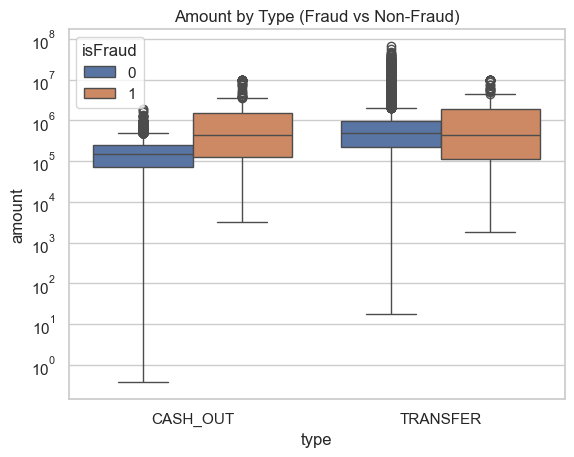

In [8]:
subset = df[df["type"].isin(["TRANSFER", "CASH_OUT"])].sample(150_000)

sns.boxplot(data=subset, x="type", y="amount", hue="isFraud")
plt.yscale("log")
plt.title("Amount by Type (Fraud vs Non-Fraud)")
plt.show()

### Transaction Amount Analysis

Transactions amounts were analyzed using boxplots and log scaling.

**Observations
-Fraud transactions tend to have higher amounts
-There is overlap between fraud and non fraud distributions

**Thoughts
Even though fraud is associated with higher transaction amounts, amount alone doesn't seperate fraud from non fraud.
These plots are informative but might yield more insight if combined with other features.

In [11]:
df.groupby('isFraud')[[
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest'
]].mean()

,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
isFraud,,,,
0,4.287969e+04,15567.699347,1.706998e+06,2.052024e+06
1,1.649668e+06,192392.631836,5.442496e+05,1.279708e+06


In [12]:
# Check sender balance math
df["orig_balance_error"] = df["oldbalanceOrg"] - df["amount"] - df["newbalanceOrig"]

# Check receiver balance math
df["dest_balance_error"] = df["oldbalanceDest"] + df["amount"] - df["newbalanceDest"]

# Compare average error for fraud vs non-fraud
print(df.groupby("isFraud")[["orig_balance_error", "dest_balance_error"]].mean())

# Count how often the balance math is not exact
df["orig_math_broken"] = df["orig_balance_error"] != 0
df["dest_math_broken"] = df["dest_balance_error"] != 0

print(df.groupby("isFraud")[["orig_math_broken", "dest_math_broken"]].mean())

         orig_balance_error  dest_balance_error
isFraud                                        
0            -286803.509954       -30910.325352
1             -10692.325265       732509.301069
         orig_math_broken  dest_math_broken
isFraud                                    
0                0.939899          0.420267
1                0.015463          0.648241


<Axes: xlabel='isFraud', ylabel='dest_balance_error'>

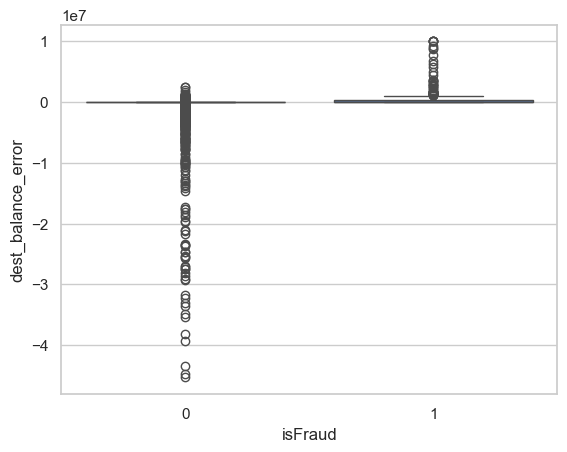

In [13]:
sns.boxplot(data=df.sample(100000), x='isFraud', y='dest_balance_error')

In [14]:
pd.crosstab(df['dest_math_broken'], df['isFraud'], normalize='index')

isFraud,0,1
dest_math_broken,,
False,0.998199,0.001801
True,0.995435,0.004565


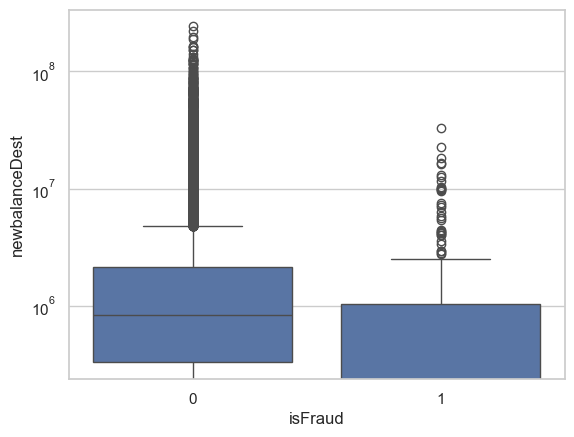

In [15]:
sns.boxplot(data=df.sample(100000), x='isFraud', y='newbalanceDest')
plt.yscale('log')

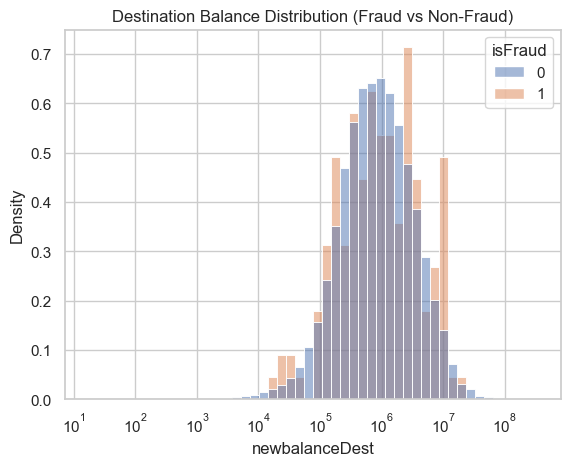

In [16]:
sns.histplot(
    data=df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].sample(100000),
    x='newbalanceDest',
    hue='isFraud',
    log_scale=True,
    stat='density',
    common_norm=False,
    bins=50
)
plt.title("Destination Balance Distribution (Fraud vs Non-Fraud)")
plt.show()

In [17]:
df = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()
pd.qcut(df['newbalanceDest'], q=5, duplicates='drop')

2                  (-0.001, 261641.32]
3                  (-0.001, 261641.32]
15                 (-0.001, 261641.32]
19                 (-0.001, 261641.32]
24         (2674426.574, 356179278.92]
                      ...             
6362615        (261641.32, 579163.954]
6362616            (-0.001, 261641.32]
6362617    (2674426.574, 356179278.92]
6362618            (-0.001, 261641.32]
6362619    (2674426.574, 356179278.92]
Name: newbalanceDest, Length: 2770409, dtype: category
Categories (5, interval[float64, right]): [(-0.001, 261641.32] < (261641.32, 579163.954] < (579163.954, 1182581.906] < (1182581.906, 2674426.574] < (2674426.574, 356179278.92]]

In [18]:
df.groupby('isFraud')[['orig_balance_error', 'dest_balance_error']].median()

,orig_balance_error,dest_balance_error
isFraud,,
0,-144200.825,0.00
1,0.000,2231.46


In [19]:
df['dest_error_flag'] = (df['dest_balance_error'].abs() > 1)

df.groupby('dest_error_flag')['isFraud'].mean()

dest_error_flag
False    0.001590
True     0.015705
Name: isFraud, dtype: float64

In [20]:
df.groupby(['type', 'dest_error_flag'])['isFraud'].mean()

type      dest_error_flag
CASH_OUT  False              0.001962
          True               0.000671
TRANSFER  False              0.000006
          True               0.070510
Name: isFraud, dtype: float64

In [25]:
numeric_cols = [
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest',
    'orig_balance_error',
    'dest_balance_error',
    'isFraud'
]

corr = df[numeric_cols].corr()

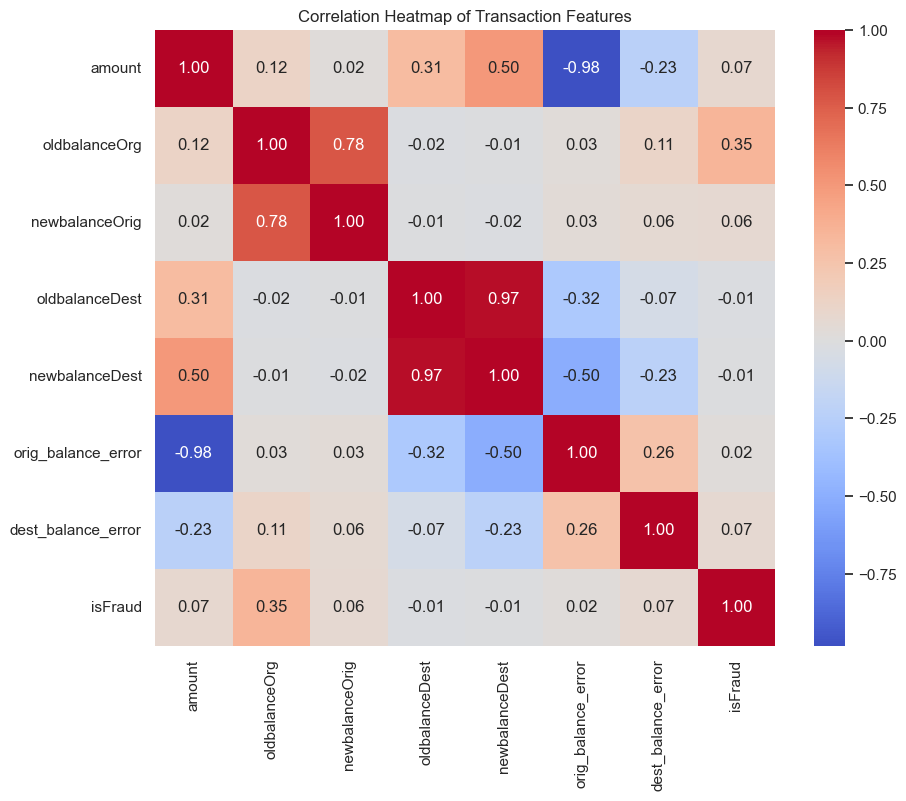

In [27]:


plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Transaction Features")
plt.show()
subset = df.sample(100000)  # for performance


### Correlation Heatmap

A correlation heatmap was used to examine relationships between numerical features.

**Observations
-strong correlations exist between related balance features (old vs new balances)
-engineered features (balance errors) show meaningful relationships with transactions attributes
-Individual features show weak linear correlation with fraud

##Thoughts 
Fraud detection will likely depend on combinations of features instead of a single variable.
